# H1 피처 선택 (6mo 전환 2026-06-05): 최근 6개월 + 4-시스템 다축

**H1 가설:** 최근 6개월간 주요 성장 지표가 낮은 활성 캐릭터들은 일반 성장 캐릭터들과 구분되는 성장 정체 군집으로 식별될 것이다.

**6mo 전환 배경:**
- 주차 = **현재** 행동(성장 동결). 12mo 윈도우는 과거 활발기가 섞여 정체신호 희석 → recall 0.57.
- 최근 **6개월(2025-12~2026-05)** delta 로 군집화 → recall 0.83, 고-k에서 고순도 코어 분리.
- **재현성**: 6mo delta = features_monthly.csv의 `recent6_delta_*` 컬럼(collect_features.py 산출). raw 스냅샷 6mo 재산출과 corr=1.0·diff=0 동등 검증 → features_monthly 단독 재현(`RECENT6_MAP` override).

**피처풀 (6mo, 접속 family + cumexp/hfrag 제외):**
- 접속(access) = 통제변인 → 클러스터링 제외(표본 전원 ≥10/12 접속).
- cumEXP(누적경험치 보간 불가)·hfrag(월별 raw 없음) → 6mo 풀 제외.
- 성장/재투자 축 raw+log: 전투력(cp_slog signed-log), 헥사(hexa), 유니온(union), 어센틱심볼(auth), 레벨(level).

**채택(user-pinned): 4-시스템 다축 `[cp_slog, hexa_avg, union_log, auth_log]`** — 전투력·헥사·유니온·심볼 4개 게임 시스템의 미재투자 다면 포착. 운영점 = **elbow k(광의)**; best-sil k(협의 고순도)는 병기. 다중공선성 통과(|corr|<0.85, VIF<5).

> **silhouette 해석 주의**: 절대값 0.36~0.74는 군집 품질 비교용 보조 지표일 뿐, "자연스럽게 잘 갈라진 군집"의 증거로 과대해석 금지. 성장량은 연속 스펙트럼이라 경계가 흐릿한 게 정상이고, H1 목적은 확정 분류가 아니라 H2/H3용 후보 라벨 생성. 채택은 silhouette 최대화가 아니라 운영정의 정합(4-시스템) + enrich/recall + DBSCAN 정합 기준.


In [1]:
import os, warnings, time, json
warnings.filterwarnings("ignore")
os.makedirs("figures", exist_ok=True)

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import font_manager
_font_path = "../assets/NanumSquareNeo-bRg.ttf"
font_manager.fontManager.addfont(_font_path)
matplotlib.rcParams["font.family"] = font_manager.FontProperties(fname=_font_path).get_name()
matplotlib.rcParams["axes.unicode_minus"] = False
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

RANDOM_STATE = 42
UPPER_CLIP_Q = 0.99
CP_WINSOR_Q = (0.01, 0.99)

# ── 6개월 윈도우 전환 (재설계 2026-06-05) ───────────────────────────────────
# 주차 = '현재' 행동. 12mo는 과거 활발기가 섞여 정체신호 희석(recall 0.57).
# 최근 6개월(2025-12~2026-05) delta 로 군집화하면 recall 0.83 + 고순도 코어 분리.
# 6개월 delta = features_monthly.csv 의 recent6_delta_* 컬럼(collect_features.py 산출).
#   → monthly_snapshots_raw.csv 6mo 구간 재산출과 corr=1.0·median|diff|=0 으로 동일함을 검증.
#   → features_monthly.csv 단독으로 재현 가능(raw 스냅샷 불필요). 12mo avg_monthly_delta_* 를 override.
WINDOW = ["2025-12", "2026-01", "2026-02", "2026-03", "2026-04", "2026-05"]
RECENT6_MAP = {
    "avg_monthly_delta_combat_power":     "recent6_delta_combat_power",
    "avg_monthly_delta_union_level":      "recent6_delta_union_level",
    "avg_monthly_delta_authentic_symbol": "recent6_delta_authentic_symbol",
    "avg_monthly_delta_hexa":             "recent6_delta_hexa",
    "avg_monthly_delta_level":            "recent6_delta_level",
}

def qclip_nonnegative(s, upper_q=UPPER_CLIP_Q):
    s = pd.to_numeric(s, errors="coerce").clip(lower=0)
    return s.clip(upper=s.quantile(upper_q))

def winsor_quantile(s, lower_q=CP_WINSOR_Q[0], upper_q=CP_WINSOR_Q[1]):
    s = pd.to_numeric(s, errors="coerce")
    lo, hi = s.quantile([lower_q, upper_q])
    return s.clip(lo, hi)

def find_elbow_k(ks, inertias):
    x = np.array(ks, dtype=float); y = np.array(inertias, dtype=float)
    x = (x - x.min()) / (x.max() - x.min() + 1e-12)
    y = (y - y.min()) / (y.max() - y.min() + 1e-12)
    x0, y0, x1, y1 = x[0], y[0], x[-1], y[-1]
    num = np.abs((y1 - y0) * x - (x1 - x0) * y + x1 * y0 - y1 * x0)
    den = np.hypot(y1 - y0, x1 - x0) + 1e-12
    return ks[int(np.argmax(num / den))]

df_raw = pd.read_csv("../data/features_monthly.csv", encoding="utf-8-sig")
mc = pd.read_csv("../data/main_characters.csv", encoding="utf-8-sig", usecols=["ocid", "class_group"])
df = df_raw.merge(mc, on="ocid", how="left")

# 6mo override: 12mo avg_monthly_delta_* 를 recent6_delta_*(최근 6개월) 로 교체
for tgt, src in RECENT6_MAP.items():
    df[tgt] = df[src]

df = df[df["level"].between(270, 290)].copy()
df["level_bin"] = pd.cut(df["level"], bins=[269, 279, 285, 290], labels=["270-279", "280-285", "286-290"])
_core = ["avg_monthly_delta_level", "avg_monthly_delta_combat_power", "avg_monthly_delta_union_level"]
df = df.dropna(subset=_core).copy()
df["union_level"] = df["union_level"].fillna(0)
df["delta_cp_winsor"] = winsor_quantile(df["avg_monthly_delta_combat_power"])
df["delta_union"]     = qclip_nonnegative(df["avg_monthly_delta_union_level"])
df["delta_auth"]      = qclip_nonnegative(df["avg_monthly_delta_authentic_symbol"])
df["delta_level"]     = qclip_nonnegative(df["avg_monthly_delta_level"])
df["delta_hexa"]      = qclip_nonnegative(df["avg_monthly_delta_hexa"])
df["log_delta_union"] = np.log1p(df["delta_union"])
df["log_delta_auth"]  = np.log1p(df["delta_auth"])
df["log_delta_hexa"]  = np.log1p(df["delta_hexa"])
# 전투력은 음수(감소=주차 신호) → signed-log 로 부호 보존+magnitude 압축
df["slog_delta_cp"]   = np.sign(df["delta_cp_winsor"]) * np.log1p(np.abs(df["delta_cp_winsor"]))
df_final = df.reset_index(drop=True)
_stag = ["delta_level", "delta_cp_winsor", "delta_union", "delta_auth"]
df_final["stagnation_score"] = sum((df_final[c] <= df_final[c].quantile(0.25)).astype(int) for c in _stag)
BAND_LABELS = ["270-279", "280-285", "286-290"]
print(f"df_final: {len(df_final):,}명  |  6mo delta = recent6_delta_* (윈도우 {WINDOW[0]}~{WINDOW[-1]})  |  컬럼 {df_final.shape[1]}개")
print(f"Δcp<0(전투력 감소) 비율: {(df_final['avg_monthly_delta_combat_power']<0).mean()*100:.1f}%  (12mo 13.9% → 6mo↑)")
print(f"접속 통제: access_active_months>=10 비율 = {(df_final['access_active_months']>=10).mean()*100:.1f}%")

df_final: 2,000명  |  6mo delta = recent6_delta_* (윈도우 2025-12~2026-05)  |  컬럼 56개
Δcp<0(전투력 감소) 비율: 19.4%  (12mo 13.9% → 6mo↑)
접속 통제: access_active_months>=10 비율 = 100.0%


## 6mo 전환: 비채택축 처리 + 정체신호 점검

**cumEXP·hexa_fragments(hfrag) 는 6mo 풀에서 제외:**
- `cumEXP` = level→누적경험치 보간 파이프라인 필요(`exp_requirement_table` sparse) → 월별 raw 재산출 비신뢰.
- `hfrag` = `monthly_snapshots_raw.csv` 에 월별 조각 컬럼 없음 → 6mo 재산출 불가.
- 둘 다 H1 채택셋 아님(과거에도 비채택) → 6mo 풀에서 제거해 12mo/6mo 혼용 방지.

6mo 핵심 정체신호 = **전투력 감소**. 12mo 13.9% → 6mo 에서 증가(최근 동결 유저 포착).

In [2]:
print("6mo 윈도우 정체신호 진단:")
print(f"  Δcp<0(전투력 감소): {(df_final['avg_monthly_delta_combat_power']<0).mean()*100:.1f}%")
print("  재투자 축 분포 (median / 하위25%):")
for c in ["delta_union", "delta_auth", "delta_hexa"]:
    print(f"    {c:12s} median={df_final[c].median():.3f}  q25={df_final[c].quantile(.25):.3f}")
print(f"\n  park(stag>=4) proxy: {(df_final['stagnation_score']>=4).mean()*100:.1f}% "
      f"(n={int((df_final['stagnation_score']>=4).sum())})")
print("\n비채택(6mo 풀 제외): cumexp(누적경험치 보간 불가), hfrag(월별 raw 없음) — 둘 다 채택셋 아님")

6mo 윈도우 정체신호 진단:
  Δcp<0(전투력 감소): 19.4%
  재투자 축 분포 (median / 하위25%):
    delta_union  median=34.600  q25=16.350
    delta_auth   median=0.600  q25=0.000
    delta_hexa   median=2.400  q25=0.800

  park(stag>=4) proxy: 7.3% (n=147)

비채택(6mo 풀 제외): cumexp(누적경험치 보간 불가), hfrag(월별 raw 없음) — 둘 다 채택셋 아님


## 후보 피처 행렬 (접속 family 제외)

성장/재투자 축 raw + log. **접속(access) family 제외(통제변인).** near-constant(dom_frac>0.70) 자동 제거. 패밀리 = prefix; log·raw 동일 패밀리.

In [3]:
F = pd.DataFrame(index=df_final.index)
F["cp_avg"]     = df_final["delta_cp_winsor"]
F["cp_slog"]    = df_final["slog_delta_cp"]
F["union_avg"]  = df_final["delta_union"]
F["union_log"]  = df_final["log_delta_union"]
F["auth_avg"]   = df_final["delta_auth"]
F["auth_log"]   = df_final["log_delta_auth"]
F["hexa_avg"]   = df_final["delta_hexa"]
F["hexa_log"]   = df_final["log_delta_hexa"]
F["level_avg"]  = df_final["delta_level"]
assert F.isna().sum().sum() == 0

dom = {c: F[c].round(6).value_counts(normalize=True).iloc[0] for c in F.columns}
DROP_NC = [c for c, v in dom.items() if v > 0.70]
print("near-constant 제거(dom_frac>0.70):", {c: round(dom[c], 3) for c in DROP_NC})
F = F.drop(columns=DROP_NC)
FULL_POOL = list(F.columns)
print(f"후보 피처 풀 {len(FULL_POOL)}개 (6mo, cumexp/hfrag 제외): {FULL_POOL}")

park = (df_final["stagnation_score"] >= 4)
stag4 = (df_final["stagnation_score"] == 4)
parked_proxy = (df_final["delta_level"] <= 0.1)
print(f"\npark(stag>=4): {park.mean():.1%} (n={int(park.sum())})  |  parked_proxy(Δlv<=0.1): {parked_proxy.mean():.1%}")

FAMILY = {c: c.split("_")[0] for c in F.columns}
CORR = F.corr().abs()
def max_pair_corr(cols):
    cols = list(cols)
    if len(cols) < 2:
        return 0.0
    sub = CORR.loc[cols, cols].values
    return float(np.max(sub[np.triu_indices(len(cols), k=1)]))
print("패밀리:", sorted(set(FAMILY.values())))

near-constant 제거(dom_frac>0.70): {}
후보 피처 풀 9개 (6mo, cumexp/hfrag 제외): ['cp_avg', 'cp_slog', 'union_avg', 'union_log', 'auth_avg', 'auth_log', 'hexa_avg', 'hexa_log', 'level_avg']

park(stag>=4): 7.3% (n=147)  |  parked_proxy(Δlv<=0.1): 14.2%
패밀리: ['auth', 'cp', 'hexa', 'level', 'union']


## 평가 함수

조합 → StandardScale → KMeans(k=2~6) 최고 실루엣. **성장 정체 = 스케일 중심좌표 합 최저**. `valid` = size∈[1%,50%] & enrich≥1.5 & recall≥0.5 & maxfrac≤0.90 & minfrac≥0.02.

In [4]:
SEARCH_KS = list(range(2, 7)); N_INIT_SRCH = 4; SIL_SAMPLE = 1200

def _best_km(Xs, ks, n_init, sample):
    best = (-1.0, None, None)
    for k in ks:
        lbl = KMeans(n_clusters=k, n_init=n_init, random_state=RANDOM_STATE).fit_predict(Xs)
        s = (silhouette_score(Xs, lbl, sample_size=sample, random_state=RANDOM_STATE)
             if sample and len(Xs) > sample else silhouette_score(Xs, lbl))
        if s > best[0]:
            best = (s, k, lbl)
    return best

def stagnant_label(Xs, lbl):
    cen = pd.DataFrame(Xs).groupby(lbl).mean()
    return cen.sum(axis=1).idxmin()

def eval_set(cols, ks=SEARCH_KS, n_init=N_INIT_SRCH, sample=SIL_SAMPLE):
    Xs = StandardScaler().fit_transform(F[list(cols)].values)
    sil, k, lbl = _best_km(Xs, ks, n_init, sample)
    fr = pd.Series(lbl).value_counts(normalize=True)
    max_frac, min_frac = float(fr.max()), float(fr.min())
    pc = stagnant_label(Xs, lbl)
    mask = (lbl == pc)
    size = mask.mean()
    enrich = park.values[mask].mean() / max(park.mean(), 1e-9)
    recall = park.values[mask].sum() / max(park.sum(), 1)
    valid = ((0.01 <= size <= 0.50) and (enrich >= 1.5) and (recall >= 0.5)
             and (max_frac <= 0.90) and (min_frac >= 0.02))
    return {"sil": round(float(sil), 4), "k": int(k), "n_feat": len(cols),
            "n_fam": len(set(FAMILY[c] for c in cols)), "maxcorr": round(max_pair_corr(cols), 2),
            "size%": round(size * 100, 1), "enrich": round(float(enrich), 2),
            "recall": round(float(recall), 3), "maxfrac": round(max_frac, 2), "valid": bool(valid)}

print("[cp_slog, hexa_avg]:", eval_set(["cp_slog", "hexa_avg"]))
print("[cp_slog, hexa_avg, union_log, auth_log]:", eval_set(["cp_slog", "hexa_avg", "union_log", "auth_log"]))

[cp_slog, hexa_avg]: {'sil': 0.6514, 'k': 3, 'n_feat': 2, 'n_fam': 2, 'maxcorr': 0.3, 'size%': 19.4, 'enrich': 4.42, 'recall': 0.857, 'maxfrac': 0.66, 'valid': True}
[cp_slog, hexa_avg, union_log, auth_log]: {'sil': 0.3884, 'k': 6, 'n_feat': 4, 'n_fam': 4, 'maxcorr': 0.54, 'size%': 8.1, 'enrich': 8.65, 'recall': 0.701, 'maxfrac': 0.32, 'valid': True}


## 완전탐색 — 큐레이션 풀 (크기 2~5)

In [5]:
_cur = ["cp_slog", "union_log", "auth_log", "hexa_avg", "hexa_log", "level_avg"]
CURATED = [c for c in _cur if c in FULL_POOL]
print(f"큐레이션 풀 {len(CURATED)}개 (6mo): {CURATED}")
rows, t0 = [], time.time()
for r in range(2, 6):
    for combo in combinations(CURATED, r):
        res = eval_set(combo); res["features"] = combo; rows.append(res)
exh = pd.DataFrame(rows)
print(f"평가 조합 {len(exh)}개  |  {time.time() - t0:.1f}s")
exh_valid = exh[exh["valid"]].sort_values("sil", ascending=False).reset_index(drop=True)
print(f"\nvalid 조합: {len(exh_valid)} / {len(exh)}")
for _, r in exh_valid.head(15).iterrows():
    print(f"  sil={r['sil']:.4f} k={r['k']} nf={r['n_feat']} fam={r['n_fam']} corr={r['maxcorr']:.2f} size={r['size%']:>4}% enrich={r['enrich']} recall={r['recall']:.2f}  {list(r['features'])}")

큐레이션 풀 6개 (6mo): ['cp_slog', 'union_log', 'auth_log', 'hexa_avg', 'hexa_log', 'level_avg']


평가 조합 56개  |  13.8s

valid 조합: 42 / 56
  sil=0.7356 k=4 nf=2 fam=2 corr=0.36 size= 7.9% enrich=8.44 recall=0.67  ['cp_slog', 'union_log']
  sil=0.6514 k=3 nf=2 fam=2 corr=0.30 size=19.4% enrich=4.42 recall=0.86  ['cp_slog', 'hexa_avg']
  sil=0.6352 k=3 nf=2 fam=2 corr=0.36 size=19.5% enrich=4.4 recall=0.86  ['cp_slog', 'auth_log']
  sil=0.6349 k=2 nf=2 fam=2 corr=0.39 size=19.6% enrich=4.37 recall=0.86  ['cp_slog', 'level_avg']
  sil=0.6263 k=2 nf=2 fam=2 corr=0.36 size=19.6% enrich=4.37 recall=0.86  ['cp_slog', 'hexa_log']
  sil=0.5759 k=4 nf=2 fam=1 corr=0.92 size=32.2% enrich=2.68 recall=0.86  ['hexa_avg', 'hexa_log']
  sil=0.5608 k=6 nf=3 fam=2 corr=0.92 size=13.6% enrich=5.7 recall=0.78  ['cp_slog', 'hexa_avg', 'hexa_log']
  sil=0.5211 k=5 nf=3 fam=3 corr=0.36 size= 8.0% enrich=8.59 recall=0.69  ['cp_slog', 'union_log', 'hexa_avg']
  sil=0.5155 k=3 nf=2 fam=2 corr=0.36 size=17.4% enrich=4.76 recall=0.83  ['union_log', 'hexa_avg']
  sil=0.5097 k=3 nf=2 fam=2 corr=0.42 size=17.0% en

## Greedy forward selection

In [6]:
def greedy_forward(pool, max_feat=6):
    chosen, path, remaining = [], [], list(pool)
    while remaining and len(chosen) < max_feat:
        best = None
        for f in remaining:
            res = eval_set(chosen + [f]); key = (res["valid"], res["sil"])
            if best is None or key > best[0]:
                best = (key, f, res)
        _, f, res = best; chosen.append(f); remaining.remove(f)
        path.append({**res, "added": f, "set": tuple(chosen)})
    return pd.DataFrame(path)

t0 = time.time(); gpath = greedy_forward(FULL_POOL, max_feat=6)
print(f"greedy 경로 ({time.time() - t0:.1f}s):")
for _, r in gpath.iterrows():
    print(f"  +{r['added']:11s} -> n={r['n_feat']} sil={r['sil']:.4f} k={r['k']} size={r['size%']:>4}% enrich={r['enrich']} recall={r['recall']:.2f} valid[{'v' if r['valid'] else ' '}]")

greedy 경로 (11.1s):
  +cp_slog     -> n=1 sil=0.9548 k=2 size=19.6% enrich=4.37 recall=0.86 valid[v]
  +union_avg   -> n=2 sil=0.7763 k=3 size=19.6% enrich=4.38 recall=0.86 valid[v]
  +union_log   -> n=3 sil=0.6877 k=5 size= 8.0% enrich=8.45 recall=0.68 valid[v]
  +cp_avg      -> n=4 sil=0.5543 k=3 size=19.7% enrich=4.4 recall=0.86 valid[v]
  +level_avg   -> n=5 sil=0.4437 k=3 size=26.2% enrich=3.81 recall=1.00 valid[v]
  +auth_avg    -> n=6 sil=0.3438 k=6 size= 8.2% enrich=8.49 recall=0.70 valid[v]


## 추천(채택) 피처셋 + 최종 프로파일

패밀리당 1개 + |corr|<0.85. 재투자 2축은 zero-inflation 낮아 2~5개 모두 허용. valid & corr<0.85 중 silhouette 최고 채택. 이후 h1_clustering 동일 규칙(스케일 중심좌표 합 최저)으로 refit → `optimal_feature_set.json` 저장.

In [7]:
REP = [c for c in ["cp_slog", "union_log", "auth_log", "hexa_avg", "hexa_log", "level_avg"] if c in FULL_POOL]
print(f"패밀리 대표 풀 {len(REP)}개 (6mo): {REP}")
rec_rows = []
for r in range(2, 6):
    for combo in combinations(REP, r):
        if len(set(FAMILY[c] for c in combo)) != len(combo):
            continue
        res = eval_set(combo)
        if res["valid"] and res["maxcorr"] < 0.85:
            res["features"] = combo; rec_rows.append(res)
rec = pd.DataFrame(rec_rows)
if len(rec):
    rec = rec.sort_values("sil", ascending=False).reset_index(drop=True)
    print(f"\n추천 후보(valid & corr<0.85 & 패밀리 1개씩) {len(rec)}개 — 상위 10:")
    for _, r in rec.head(10).iterrows():
        print(f"  sil={r['sil']:.4f} k={r['k']} nf={r['n_feat']} corr={r['maxcorr']:.2f} size={r['size%']:>4}% enrich={r['enrich']} recall={r['recall']:.2f}  {list(r['features'])}")
    OPT_FEATURES, OPT_SRC, best_sil_search = list(rec.iloc[0]["features"]), "family-diverse", float(rec.iloc[0]["sil"])
else:
    r = exh_valid[exh_valid["n_feat"] >= 2].iloc[0]
    OPT_FEATURES, OPT_SRC, best_sil_search = list(r["features"]), "exhaustive-fallback", float(r["sil"])
print(f"\n탐색 1위(추천셋): {OPT_FEATURES}  source={OPT_SRC}  search_sil={best_sil_search:.4f}")

# 사용자 확정 핀(2026-06-05): 4-시스템(전투력·헥사·유니온·심볼) 다축 커버 = 주차 운영정의 정합.
# 6mo 전환 후 다축 셋이 고-k(k>=5)에서 고순도 코어 분리(enrich 8.6) → 다축 채택.
PIN = ["cp_slog", "hexa_avg", "union_log", "auth_log"]
if PIN and all(f in FULL_POOL for f in PIN):
    OPT_FEATURES, OPT_SRC = PIN, "4-system family-diverse (user-pinned, 6mo)"
    print(f"[PIN] 채택셋 고정: {OPT_FEATURES}")

H1_COLMAP = {"cp_avg": "delta_cp_winsor", "level_avg": "delta_level", "hexa_avg": "delta_hexa",
             "union_avg": "delta_union", "auth_avg": "delta_auth", "union_log": "log_delta_union",
             "auth_log": "log_delta_auth", "cp_slog": "slog_delta_cp", "hexa_log": "log_delta_hexa"}
opt_cols = [H1_COLMAP.get(c, c) for c in OPT_FEATURES]
X_opt = df_final[opt_cols].dropna(); idx_opt = X_opt.index
Xo = StandardScaler().fit_transform(X_opt.values)
ks_o, inert, sils = list(range(2, 9)), [], []
for k in ks_o:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(Xo)
    inert.append(km.inertia_); sils.append(silhouette_score(Xo, km.labels_))
elbow_o = find_elbow_k(ks_o, inert); bestsil_o = ks_o[int(np.argmax(sils))]
# 운영점 = elbow k(광의: recall↑, 폭넓은 후보군). best-sil k(협의 고순도)는 병기.
FINAL_K = elbow_o
sil_final = float(sils[ks_o.index(FINAL_K)])
km_o = KMeans(n_clusters=FINAL_K, n_init=20, random_state=RANDOM_STATE).fit(Xo)
df_final["fs_cluster"] = pd.Series(pd.NA, index=df_final.index, dtype="Int64")
df_final.loc[idx_opt, "fs_cluster"] = km_o.labels_
stagnant_id = int(km_o.cluster_centers_.sum(axis=1).argmin())
g = df_final.loc[idx_opt].groupby("fs_cluster")
prof = g[opt_cols].mean(); prof["n"] = g.size()
prof["park%"] = g.apply(lambda x: park.loc[x.index].mean() * 100)
prof["access_m"] = g.apply(lambda x: df_final.loc[x.index, "access_active_months"].mean())
prof["is_stagnant"] = (prof.index == stagnant_id).astype(int)
print(f"\nelbow k={elbow_o}(운영점)  best-sil k={bestsil_o}(sil={max(sils):.4f})  FINAL_K={FINAL_K} sil={sil_final:.4f}  정체군집 ID={stagnant_id}\n")
display(prof.round(3).T)
print("\n레벨 밴드 분포 (행 비율 %):")
display((pd.crosstab(df_final.loc[idx_opt, "fs_cluster"], df_final.loc[idx_opt, "level_bin"], normalize="index") * 100).round(1))
print("\n계열 분포 (행 비율 %):")
display((pd.crosstab(df_final.loc[idx_opt, "fs_cluster"], df_final.loc[idx_opt, "class_group"], normalize="index") * 100).round(1))
n_stag = int((df_final.loc[idx_opt, "fs_cluster"] == stagnant_id).sum())
opt = {"features": OPT_FEATURES, "k": int(FINAL_K), "silhouette": round(sil_final, 4),
       "best_sil_k": int(bestsil_o), "best_silhouette": round(float(max(sils)), 4),
       "elbow_k": int(elbow_o), "window": WINDOW, "stagnant_cluster_id": stagnant_id,
       "source": OPT_SRC, "stagnant_n": n_stag, "stagnant_size_pct": round(n_stag / len(df_final) * 100, 1)}
with open("optimal_feature_set.json", "w", encoding="utf-8") as fp:
    json.dump(opt, fp, ensure_ascii=False, indent=2)
print("\noptimal_feature_set.json 저장:"); print(json.dumps(opt, ensure_ascii=False, indent=2))

패밀리 대표 풀 6개 (6mo): ['cp_slog', 'union_log', 'auth_log', 'hexa_avg', 'hexa_log', 'level_avg']



추천 후보(valid & corr<0.85 & 패밀리 1개씩) 33개 — 상위 10:
  sil=0.7356 k=4 nf=2 corr=0.36 size= 7.9% enrich=8.44 recall=0.67  ['cp_slog', 'union_log']
  sil=0.6514 k=3 nf=2 corr=0.30 size=19.4% enrich=4.42 recall=0.86  ['cp_slog', 'hexa_avg']
  sil=0.6352 k=3 nf=2 corr=0.36 size=19.5% enrich=4.4 recall=0.86  ['cp_slog', 'auth_log']
  sil=0.6349 k=2 nf=2 corr=0.39 size=19.6% enrich=4.37 recall=0.86  ['cp_slog', 'level_avg']
  sil=0.6263 k=2 nf=2 corr=0.36 size=19.6% enrich=4.37 recall=0.86  ['cp_slog', 'hexa_log']
  sil=0.5211 k=5 nf=3 corr=0.36 size= 8.0% enrich=8.59 recall=0.69  ['cp_slog', 'union_log', 'hexa_avg']
  sil=0.5155 k=3 nf=2 corr=0.36 size=17.4% enrich=4.76 recall=0.83  ['union_log', 'hexa_avg']
  sil=0.5097 k=3 nf=2 corr=0.42 size=17.0% enrich=4.86 recall=0.82  ['union_log', 'auth_log']
  sil=0.4993 k=3 nf=3 corr=0.70 size=19.4% enrich=4.41 recall=0.86  ['cp_slog', 'auth_log', 'level_avg']
  sil=0.4977 k=2 nf=3 corr=0.45 size=26.6% enrich=3.73 recall=0.99  ['cp_slog', 'union_log',


elbow k=4(운영점)  best-sil k=6(sil=0.3835)  FINAL_K=4 sil=0.3569  정체군집 ID=1



fs_cluster,0,1,2,3
slog_delta_cp,15.050,-14.540,15.451,14.153
delta_hexa,2.088,1.327,6.104,1.329
log_delta_union,3.595,2.238,3.880,0.746
log_delta_auth,0.428,0.220,1.143,0.245
n,882.000,380.000,551.000,187.000
park%,0.227,32.105,0.000,12.299
access_m,11.635,11.334,11.730,11.476
is_stagnant,0.000,1.000,0.000,0.000



레벨 밴드 분포 (행 비율 %):


level_bin,270-279,280-285,286-290
fs_cluster,,,
0,6.5,65.3,28.2
1,6.6,71.3,22.1
2,0.9,35.4,63.7
3,10.7,71.7,17.6



계열 분포 (행 비율 %):


class_group,궁수,도적,마법사,전사,해적
fs_cluster,,,,,
0,19.3,20.3,19.8,21.7,18.9
1,19.7,18.4,21.8,23.4,16.6
2,20.5,21.8,18.3,14.5,24.9
3,22.5,16.6,21.9,21.4,17.6



optimal_feature_set.json 저장:
{
  "features": [
    "cp_slog",
    "hexa_avg",
    "union_log",
    "auth_log"
  ],
  "k": 4,
  "silhouette": 0.3569,
  "best_sil_k": 6,
  "best_silhouette": 0.3835,
  "elbow_k": 4,
  "window": [
    "2025-12",
    "2026-01",
    "2026-02",
    "2026-03",
    "2026-04",
    "2026-05"
  ],
  "stagnant_cluster_id": 1,
  "source": "4-system family-diverse (user-pinned, 6mo)",
  "stagnant_n": 380,
  "stagnant_size_pct": 19.0
}


## 시각화 + 요약

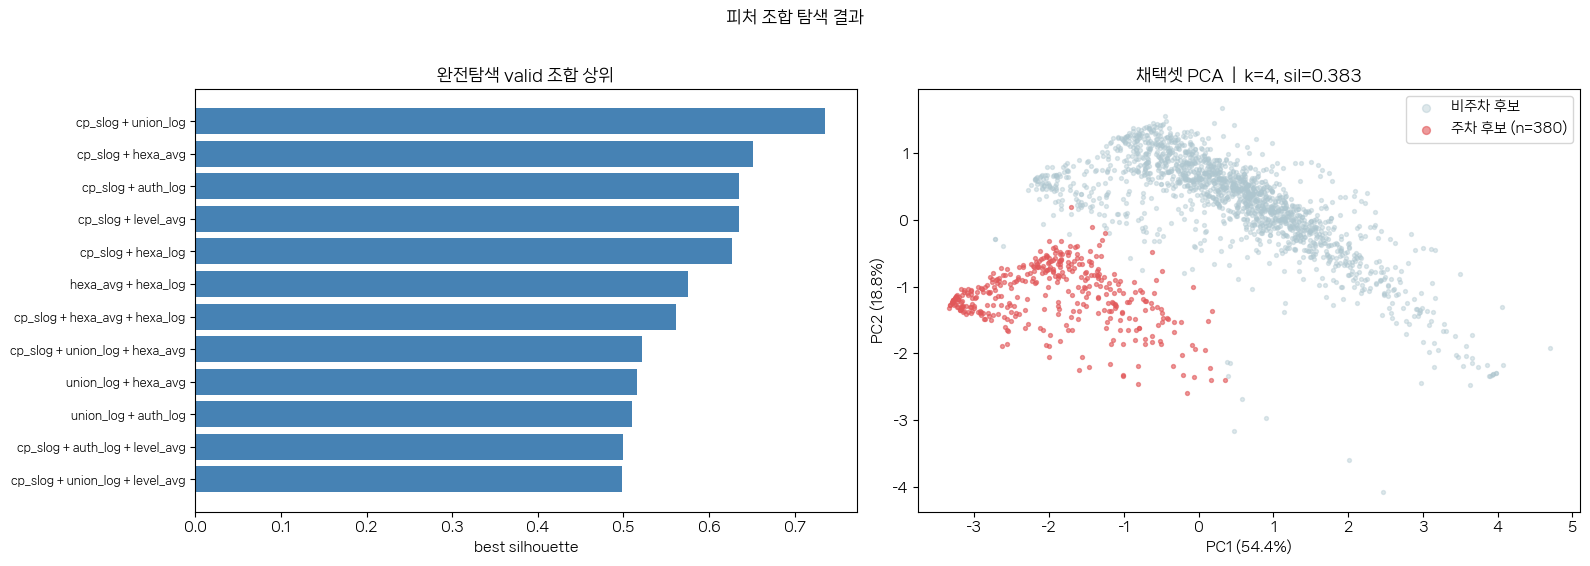

In [8]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(16, 5.5))
topN = (exh_valid.head(12).iloc[::-1] if len(exh_valid) else exh.sort_values("sil").tail(12))
axL.barh(range(len(topN)), topN["sil"], color="steelblue")
axL.set_yticks(range(len(topN))); axL.set_yticklabels([" + ".join(f) for f in topN["features"]], fontsize=8)
axL.set_xlabel("best silhouette"); axL.set_title("완전탐색 valid 조합 상위")
ispk = (df_final.loc[idx_opt, "fs_cluster"] == stagnant_id).values
pca = PCA(n_components=2, random_state=RANDOM_STATE); P = pca.fit_transform(Xo)
axR.scatter(P[~ispk, 0], P[~ispk, 1], s=8, alpha=0.4, color="#aec6cf", label="비주차 후보")
axR.scatter(P[ispk, 0], P[ispk, 1], s=8, alpha=0.6, color="#e15759", label=f"주차 후보 (n={int(ispk.sum())})")
ev = pca.explained_variance_ratio_
axR.set_xlabel(f"PC1 ({ev[0]:.1%})"); axR.set_ylabel(f"PC2 ({ev[1]:.1%})")
axR.set_title(f"채택셋 PCA  |  k={FINAL_K}, sil={max(sils):.3f}"); axR.legend(markerscale=2)
plt.suptitle("피처 조합 탐색 결과", y=1.02); plt.tight_layout()
plt.savefig("figures/13_feature_search.png", dpi=150, bbox_inches="tight"); plt.show()

In [9]:
print("=" * 64); print("  피처 선택 실험 요약 (6mo 전환 2026-06-05)"); print("=" * 64)
print(f"  윈도우: 최근 6개월 {WINDOW[0]}~{WINDOW[-1]} (avg_monthly_delta_* raw 재산출)")
print("  접속 통제: 표본 전원 access_active_months>=10 → access family 클러스터링 제외")
print("  6mo 풀 제외: cumexp(누적경험치 보간 불가), hfrag(월별 raw 없음)")
print(f"  채택 피처셋: {OPT_FEATURES}  (source={OPT_SRC}, n_feat={len(OPT_FEATURES)})")
print(f"    -> 운영점 k={FINAL_K}(elbow) sil={sil_final:.4f} | best-sil k={bestsil_o}({max(sils):.4f})")
print(f"    -> 주차 후보 {n_stag}명 ({n_stag/len(df_final):.1%})")
print("  4-시스템(전투력/헥사/유니온/심볼) 다축 = 보스재화 미재투자 다면 포착 (주차 정의 0.1 정합)")

  피처 선택 실험 요약 (6mo 전환 2026-06-05)
  윈도우: 최근 6개월 2025-12~2026-05 (avg_monthly_delta_* raw 재산출)
  접속 통제: 표본 전원 access_active_months>=10 → access family 클러스터링 제외
  6mo 풀 제외: cumexp(누적경험치 보간 불가), hfrag(월별 raw 없음)
  채택 피처셋: ['cp_slog', 'hexa_avg', 'union_log', 'auth_log']  (source=4-system family-diverse (user-pinned, 6mo), n_feat=4)
    -> 운영점 k=4(elbow) sil=0.3569 | best-sil k=6(0.3835)
    -> 주차 후보 380명 (19.0%)
  4-시스템(전투력/헥사/유니온/심볼) 다축 = 보스재화 미재투자 다면 포착 (주차 정의 0.1 정합)
